<h1><center>Laboratorio 4: EDA en Pandas 🐼</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos</strong></center>

### Cuerpo Docente:

- Profesores: Pablo Badilla, Diego Cortez
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Javiera Arévalo, Tamara Carrasco y Ignacio Reyes

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Felipe Muñoz
- Nombre de alumno 2: Antonia Landaeta R.


### **Link de repositorio de GitHub:** `https://github.com/FeLiJaNdRo/MDS7202-Labs`


## Reglas:

- **Grupos de 2 personas**
- Asistencia **obligatoria** a instrucciones del lab (viernes 16.15). Luego, pueden quedarse trabajando en las salas o irse.
- **No se revisarán entregas de personas ausentes**. 
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Prohibidas las copias. 
- Pueden usar cualquer matrial del curso que estimen conveniente.

### Objetivos principales del laboratorio

- Aplicar los paradigmas y buenas prácticas de programación vistas hasta este momento.
- Utilizar las funciones de la librería `pandas` para realizar análisis exploratorio de datos
- Aplicar principios de visualización de datos vistos en clases para mostrar patrones en los datos


El laboratorio deberá ser desarrollado sin el uso indiscriminado de iteradores nativos de python (aka "for", "while"). La idea es que aprendan a exprimir al máximo las funciones optimizadas de `pandas`.

## Descripción del laboratorio.

### Importamos librerias utiles 😸

no olvidar ejecutar esto en la consola
```bash
uv add missingno
```

In [1]:
# Libreria Core del lab.

# Libreria para plotear
import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import plotly.express as px
from IPython.display import Markdown, display
from scipy import stats

In [2]:
import plotly.io as pio
pio.renderers.default = "png"

# Segmentación de Clientes en Tienda de Retail 🛍️

<p align="center">
  <img width=300 src="https://s1.eestatic.com/2018/04/14/social/la_jungla_-_social_299733421_73842361_854x640.jpg">
</p>

## 1.1 Cargar dataset [0.5 puntos]

Mr. Lepin Mora quien es el gerente de una cotizada tienda de retail en Europa, les solicita si pueden analizar los datos de algunas de sus tiendas.

Para esto, el área de ventas les entrega el 2 archivos: `online_retail_II.pickle` y `online_retail_I.pickle`.
- Cargue ambas fuentes y asegúrese que las columnas son del tipo correcto como en el ejemplo de df_retail_1 visualizando los datos para determinar el tipo. Para fechas, puede usar `'datetime64[ns]'`
- Combine los dataframes en uno solo. ¿Qué función debe utilizar en este caso?
- Señale las columnas que componen el dataset combinado, el tipo de variable presente en cada columna y comente que representa cada una de estas.

**Respuesta:**

In [18]:
df_retail_1 = pd.read_pickle("online_retail_I.pickle")
df_retail_1 = df_retail_1.astype(
    {
        "Invoice": "category",
        "StockCode": "category",
        "Description": str,
        "Quantity": "int64",
        "Price": "float64",
        "Customer ID": "category",
        "Country": "category",
    }
)
df_retail_1.head()

,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,1.25,13085.0,United Kingdom


In [19]:
df_retail_2 = pd.read_pickle("online_retail_II.pickle")
df_retail_2 = df_retail_2.astype(
    {
        "Invoice": "category",
        "InvoiceDate": "datetime64[ns]",
    }
)
df_retail_2.head()

,Invoice,InvoiceDate
0,489434,2009-12-01 07:45:00
1,489435,2009-12-01 07:46:00
2,489436,2009-12-01 09:06:00
3,489437,2009-12-01 09:08:00
4,489438,2009-12-01 09:24:00


In [20]:
# Para combinar los dataframes, se requiere usar merge tal que ocupe como pivoteo Invoice
df_retail = pd.merge(
    left=df_retail_1,
    right=df_retail_2,
    on="Invoice",
    how="left",
    sort=True,
)
df_retail.head()

,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country,InvoiceDate
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,13085.0,United Kingdom,2009-12-01 07:45:00
1,489434,79323P,PINK CHERRY LIGHTS,12,6.75,13085.0,United Kingdom,2009-12-01 07:45:00
2,489434,79323W,WHITE CHERRY LIGHTS,12,6.75,13085.0,United Kingdom,2009-12-01 07:45:00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2.10,13085.0,United Kingdom,2009-12-01 07:45:00
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,1.25,13085.0,United Kingdom,2009-12-01 07:45:00


> Descripción del dataset:
- Invoice representa la orden de compra. Valor categórico, una orden puede tener más de un producto encargado.
- StockCode es el id del producto. Valor Categórico.
- Description es la desripción del producto. Es un script
- Quantity es la cantidad comprada de un producto. Valor numérico.
- Price es el precio del producto. Valor numérico.
- Custome ID es el id del cliente, único para cada no. Valor categórico.
- Country indica el país de origen de a orden. Valor categórico.
- InvoiceDate es la fecha de emisión de la orden de compra. Valor de formato datetime64[ns]

## 1.2 Analisís Explotatorio de los Datos [0.5 puntos] 

En base a la primera visualización del dataset, *Don Mora* le solicita que realicen un análisis exploratorio de los datos, para esto les deberán realizar un análisis univariado y multivariado. De la revisión, ustedes deben explicar potenciales anomalías visualizadas y señalar si existe la necesidad de realizar una limpieza de datos.

Explique a que nos referimos con análisis univariable, multivariable y de datos faltantes. ¿Qué beneficios nos otorga estudiar estos datos?. Sea conciso con su respuesta y no escriba mas de 5 líneas para su respuesta.

**Respuesta a la Pregunta:**

> El análisis univariable estudia cada variable por separado, permitiendo así entender la distribución, conocer los valores más frecuentes (conteo) y detectar outliers que tenga. Mientras que el análisis multivariado estudia la relación entre dos o más variables al mismo tiempo, por lo que permite ver si hay correlaciones que puedan afectar en más adelante. Por último, el análisis de datos faltantes se refiere a detectar valores faltantes en el dataset, pues su presencia puede afectar los siguientes pasos.

### 1.2.1 Análisis Univariado [1.5 Puntos]

A continuación, se le presentan dos funciones para analizar los datos que componen un dataframe. La primera de estas es la función ``profile_serie()`` la cual recibe una serie y le entrega un análisis detallado de los datos que conforman dicha serie. 

Ejecute la funcion ``profile_serie()`` sobre cada serie para realizar un análisis univariado de estas. A continuación, comente acerca de el comportamiento de cada variable según las estadísticas descriptivas y los gráficos generados.

In [6]:
from pandas.api.types import is_numeric_dtype  # noqa: I001
from pandas.api.types import is_datetime64_any_dtype, is_timedelta64_dtype


def profile_serie(serie_in, n_samples=1000, random_state=42):
    serie = serie_in.copy()

    profile = pd.Series(dtype="object")
    profile["Type"] = serie.dtype
    profile = pd.concat([profile, serie.describe()])

    # profile = pd.Series([])

    if is_numeric_dtype(serie):
        profile["Negative"] = (serie < 0).sum()
        profile["Negative (%)"] = str(round((serie < 0).sum() / len(serie) * 100, 2)) + " %"
        profile["Zeros"] = (serie == 0).sum()
        profile["Zeros (%)"] = str(round((serie == 0).sum() / len(serie) * 100, 2)) + " %"
        profile["Kurt"] = serie.kurt()
        profile["Skew"] = serie.skew()

    profile[" "] = " "  # espacio

    profile["Missing cells"] = serie.isnull().sum()
    profile["Missing cells (%)"] = str(round(serie.isnull().sum() / len(serie) * 100, 2)) + " %"
    profile["Duplicate rows"] = serie.duplicated(False).sum()
    profile["Duplicate rows (%)"] = str(round(serie.duplicated(False).sum() / len(serie) * 100, 2)) + " %"
    profile["Total size in memory"] = str(serie.memory_usage(index=True)) + " bytes"

    # profile = pd.concat([profile, description])

    profile = profile.rename(
        index={
            "count": "Number of observations",
            "mean": "Mean",
            "std": "Std",
            "min": "Min",
            "max": "Max",
            "unique": "Unique",
            "top": "Top",
            "freq": "Freq",
        }
    )
    no_outliers_fig = None

    if is_numeric_dtype(serie):
        sampled_serie = serie.sample(n_samples, random_state=random_state)
        fig = px.histogram(sampled_serie, marginal="box", title=f"{serie.name} - With Outliers")

        no_outliers = sampled_serie.loc[(np.abs(stats.zscore(sampled_serie)) < 3)]
        # zscore = https://es.wikipedia.org/wiki/Unidad_tipificada
        no_outliers_fig = px.histogram(no_outliers, marginal="box", title=f"{serie.name} - Without Outliers")

    elif is_datetime64_any_dtype(serie) or is_timedelta64_dtype(serie):
        sampled_serie = serie.sample(n_samples, random_state=random_state)
        fig = px.histogram(sampled_serie, marginal="box", title=f"{serie.name}")
    else:
        count = serie.value_counts()[0:100].reset_index().rename(columns={"count": "Count"})
        fig = px.bar(
            x=count[serie.name].astype(str),
            y=count["Count"],
            title=f"100 Most common categories of {serie.name}",
        )
    display(Markdown(f"## {serie.name} Profile"))
    display(profile)
    fig.show(renderer="png")

    if no_outliers_fig:
        no_outliers_fig.show(renderer="png")

    # return fig, profile

## Price Profile

Type                            float64
Number of observations         525461.0
Mean                           4.688834
Std                          146.126914
Min                           -53594.36
25%                                1.25
50%                                 2.1
75%                                4.21
Max                            25111.09
Negative                              3
Negative (%)                      0.0 %
Zeros                              3687
Zeros (%)                         0.7 %
Kurt                       64868.344873
Skew                        -140.768446
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   524485
Duplicate rows (%)              99.81 %
Total size in memory      4203820 bytes
dtype: object

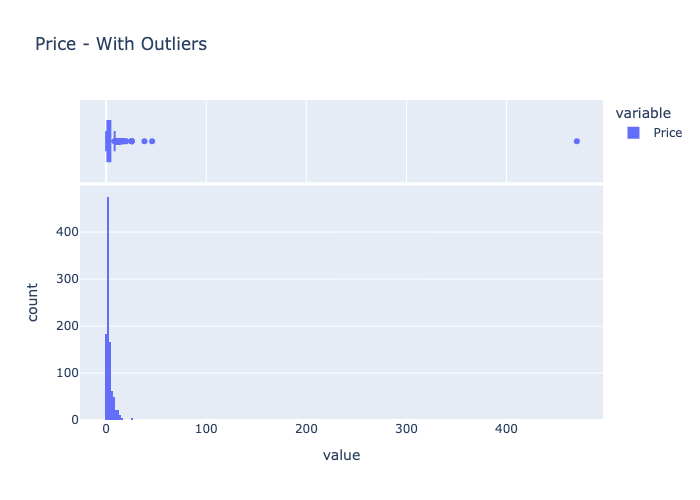

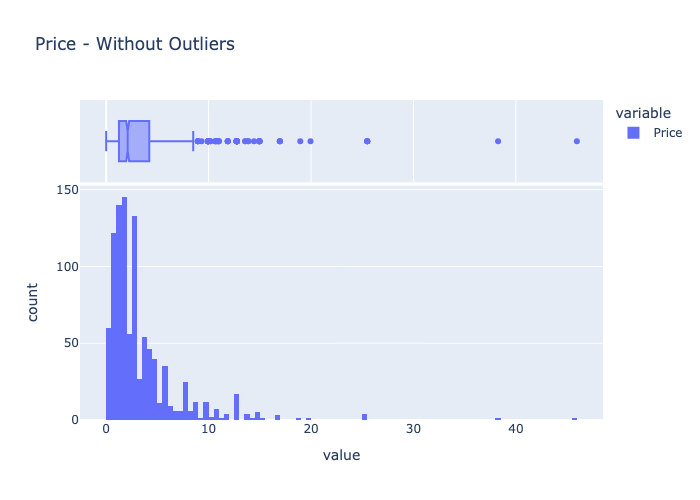

In [7]:
profile_serie(df_retail["Price"])

Para la variable Price, no se registran valores faltantes. La media es de 4,68 con una desviación estándar de 146, lo que refleja una dispersión muy alta explicada por la presencia de outliers. En particular, se observa un mínimo de −53.594, lo cual carece de sentido económico dado que un precio no puede ser negativo, y un máximo de 25.111 euros. Los cuartiles corroboran la presencia de valores extremos: el 75% de los registros tiene un precio menor o igual a 4,21 euros, lo que contrasta fuertemente con el valor máximo. La kurtosis presenta un valor elevado, indicando que la distribución está altamente concentrada en torno a precios bajos, con una cola derecha larga y delgada. El gráfico de distribución confirma este comportamiento.

Tras el tratamiento de outliers, el rango de valores es considerablemente más acotado, con un mínimo de 0 y un máximo de 45,95 euros. Se mantiene la concentración hacia los valores bajos, pero la cola derecha es significativamente más corta.

## Quantity Profile

Type                              int64
Number of observations         525461.0
Mean                          10.337667
Std                           107.42411
Min                             -9600.0
25%                                 1.0
50%                                 3.0
75%                                10.0
Max                             19152.0
Negative                          12326
Negative (%)                     2.35 %
Zeros                                 0
Zeros (%)                         0.0 %
Kurt                        6277.666908
Skew                          36.044617
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   525122
Duplicate rows (%)              99.94 %
Total size in memory      4203820 bytes
dtype: object

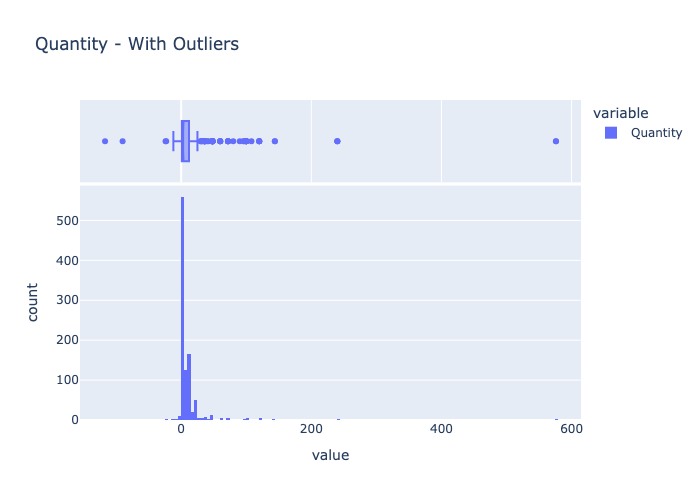

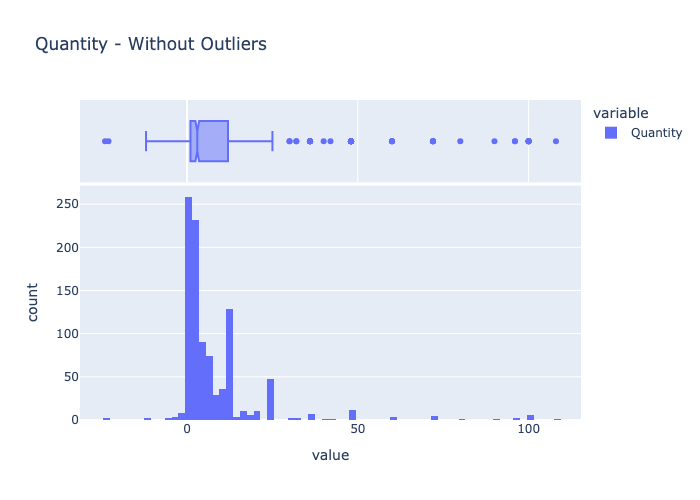

In [8]:
profile_serie(df_retail["Quantity"])

La variable Quantity presenta los mismos problemas que Price: valores extremos y registros sin sentido económico, como las cantidades negativas. La distribución sigue una tendencia similar, con los datos concentrados hacia valores bajos. Respecto a los cuartiles, el 75% de los registros corresponde a cantidades menores o iguales a 10 unidades.

Tras el tratamiento de outliers, si bien la cola de la distribución se acorta, no todos los valores negativos ni outliers fueron eliminados. Esto se explica porque el método del IQR define los límites en función de la dispersión general de los datos: dado que los valores negativos son numerosos y una parte de ellos se encuentra relativamente cerca de la media, el límite inferior calculado no fue lo suficientemente estricto como para excluirlos a todos.

### 1.2.2 Análisis Multivariado y Datos Faltantes [1 ptos]

En segundo lugar encontrará la función ``profile_df()`` que recibe un dataframe como entrada y realiza un análisis bivariado de todas las variables numéricas que conforman el dataframe, un analisis de la correlación de Pearson entre las variables numericas del dataframe y la matriz de datos faltantes.

Utilice esta función en el dataframe. Comente sobre los patrones que observa. Luego responda:
- Existen correlaciones relevantes observadas?
- Qué aspectos revelan estos gráficos acerca de la limpieza de los datos?

In [9]:
def profile_df(dataframe_in):
    df = dataframe_in.copy()

    list_type = []
    for col in list(df.columns):
        if is_numeric_dtype(df[col]) or is_datetime64_any_dtype(df[col]) or is_timedelta64_dtype(df[col]):
            list_type.append(col)

    display(Markdown("## Bivariant Analysis:"))
    for i in range(len(list_type)):
        for j in range(i + 1, len(list_type)):
            plt.scatter(df[list_type[i]], df[list_type[j]])
            plt.xlabel(list_type[i])
            plt.ylabel(list_type[j])
            plt.title(f"{list_type[i]} v/s {list_type[j]}")
            plt.show()

    display(Markdown("## Correlation:"))
    fig_corr = px.imshow(df[list_type].corr())
    fig_corr.show()

    display(Markdown("## Missing Matrix:"))
    fig, ax = plt.subplots(figsize=[15, 10])
    msno.matrix(df, ax=ax, sparkline=False)

## Bivariant Analysis:

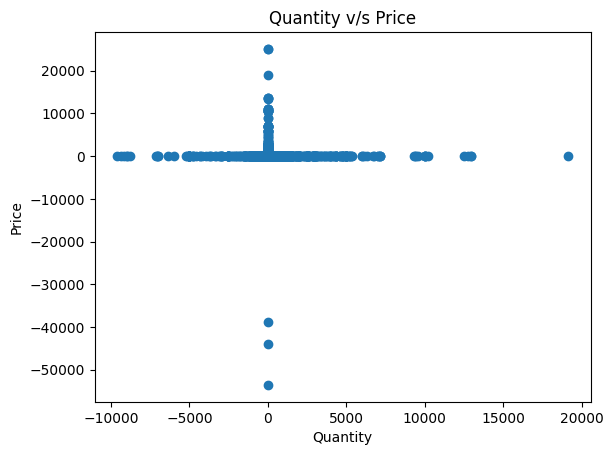

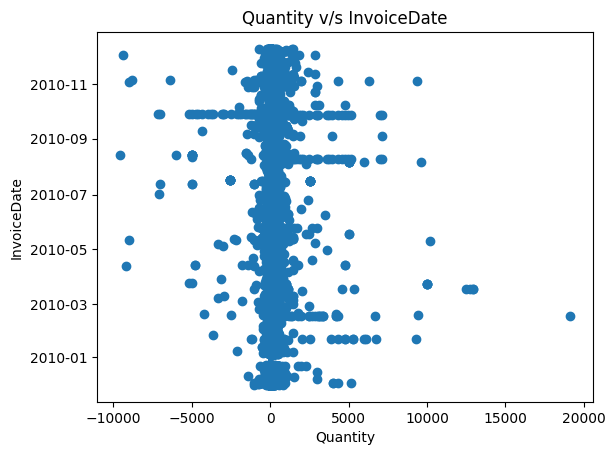

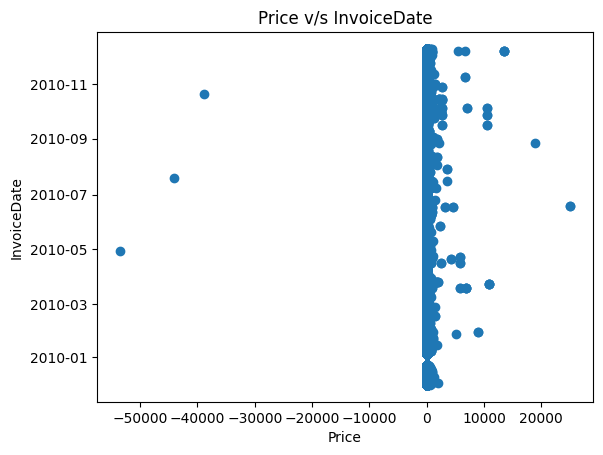

## Correlation:

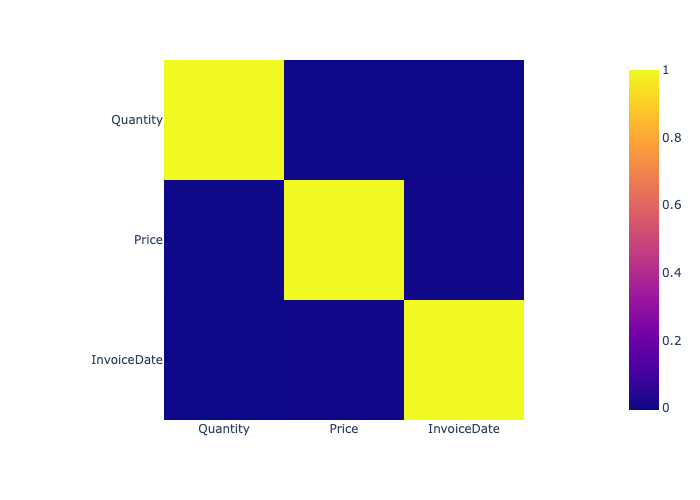

## Missing Matrix:

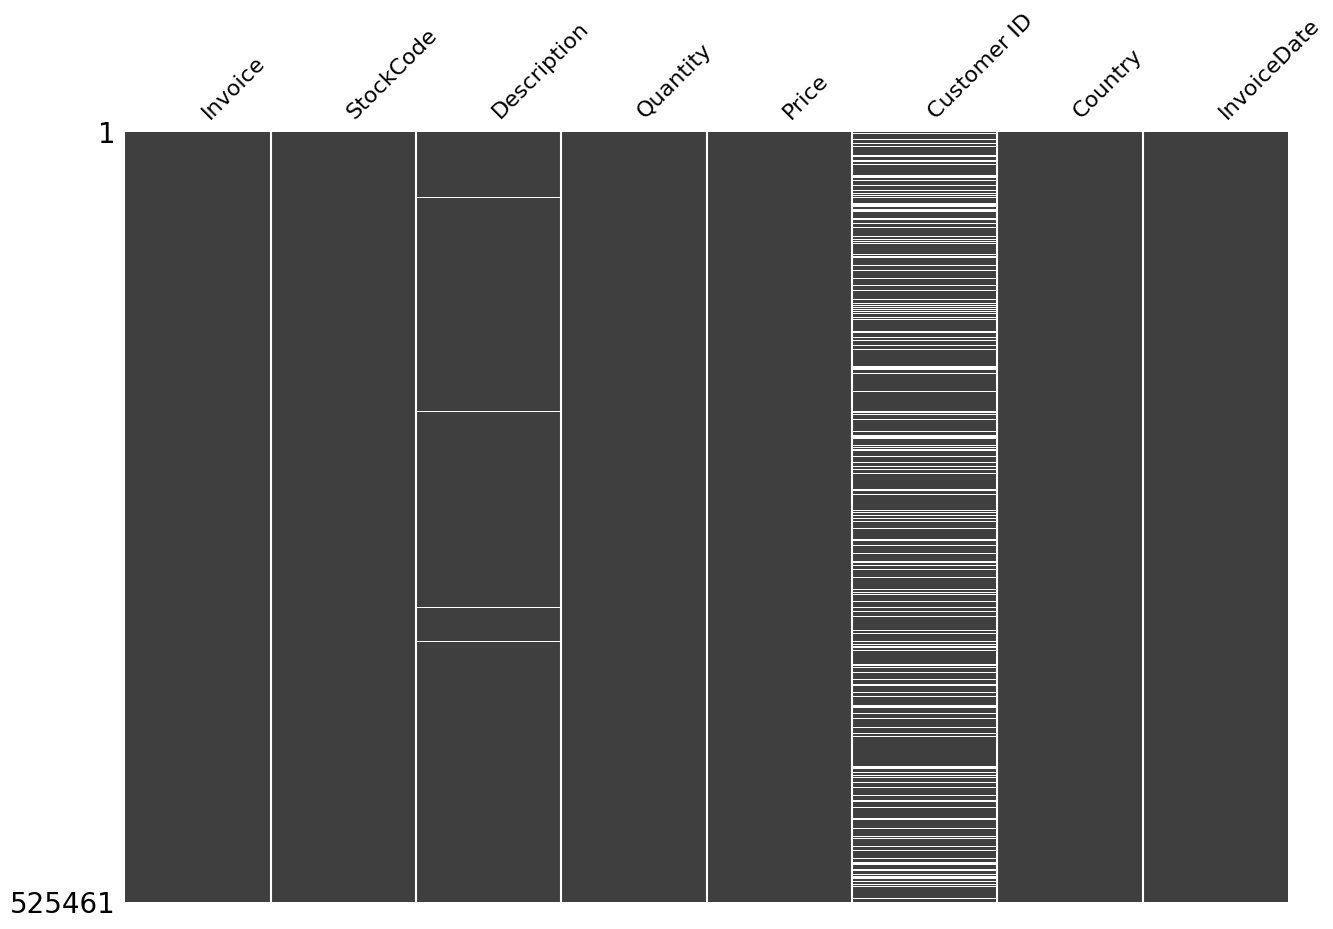

In [10]:
profile_df(df_retail)

Respecto a la matriz de correlaciones, ninguna variable presenta correlación significativa con otra, salvo consigo misma.
En cuanto al análisis bivariado:

- Quantity vs Price: la presencia de valores negativos en Quantity y la magnitud de los outliers en ambas variables impiden identificar una tendencia clara entre ellas.
- Quantity vs InvoiceDate: se observa una nube de puntos con alto nivel de ruido, sin una tendencia visible entre las variables.
- Price vs InvoiceDate: la magnitud de los outliers en Price es considerablemente mayor al rango normal de la variable, lo que dificulta identificar alguna tendencia con respecto a la fecha.

Finalmente, el análisis de valores faltantes mediante la matriz de missingness indica que la variable Description presenta 4 valores nulos, mientras que CustomerID concentra una cantidad significativamente mayor de datos faltantes.

### 1.2.3 Limpieza de Datos [1 pto]

Como pudo ver en las secciones anteriores, los datos presentan valores erroneos, es por esto que se le solicita que realice una función que permita limpiar el dataset. Realice esta función en base observaciones propias y considere como **imposible tener cantidades negativas** en las ventas. Investigue sobre métodos para eliminar outliers usando pandas

Una vez realizada la función, realice nuevamente el análisis exploratorio y comente las principales diferencias.

**Respuesta:**

In [11]:
# Sacar los valores negativos de precio y de cantidad
def limpiar(dataframe: pd.DataFrame) -> pd.DataFrame:
    df = dataframe.copy()

    # guardar nombres de columnas a modificar
    columns = ["Price", "Quantity"]

    for i in columns:
        # eliminar los valores negativos
        df = df[(df[i] > 0)]

        # rango intercuartil para tratar outliers
        # Calculate the percentiles
        q75 = df[i].quantile(0.75)
        q25 = df[i].quantile(0.25)

        # Obtain IQR
        iqr = q75 - q25

        # Upper and lower thresholds
        upper = q75 + (1.5 * iqr)
        lower = q25 - (1.5 * iqr)

        outliers = df[(df[i] < lower) | (df[i] > upper)]

        # Calculo de media
        media = int(df[i].mean())

        # Impute outliers with the median
        df.loc[outliers.index, i] = media

    df = df.reset_index(drop=True)
    return df

In [12]:
df_retail_limpio = limpiar(df_retail)
df_retail_limpio.head(10)

,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country,InvoiceDate
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,13085.0,United Kingdom,2009-12-01 07:45:00
1,489434,79323P,PINK CHERRY LIGHTS,12,6.75,13085.0,United Kingdom,2009-12-01 07:45:00
2,489434,79323W,WHITE CHERRY LIGHTS,12,6.75,13085.0,United Kingdom,2009-12-01 07:45:00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",11,2.10,13085.0,United Kingdom,2009-12-01 07:45:00
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,11,1.25,13085.0,United Kingdom,2009-12-01 07:45:00
5,489434,22064,PINK DOUGHNUT TRINKET POT,11,1.65,13085.0,United Kingdom,2009-12-01 07:45:00
6,489434,21871,SAVE THE PLANET MUG,11,1.25,13085.0,United Kingdom,2009-12-01 07:45:00
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,5.95,13085.0,United Kingdom,2009-12-01 07:45:00
8,489435,22350,CAT BOWL,12,2.55,13085.0,United Kingdom,2009-12-01 07:46:00
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,3.75,13085.0,United Kingdom,2009-12-01 07:46:00


## Price Profile

Type                            float64
Number of observations         511566.0
Mean                           2.762825
Std                            1.977878
Min                               0.001
25%                                1.25
50%                                 2.1
75%                                 4.0
Max                                8.62
Negative                              0
Negative (%)                      0.0 %
Zeros                                 0
Zeros (%)                         0.0 %
Kurt                            0.62271
Skew                           1.082478
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   511504
Duplicate rows (%)              99.99 %
Total size in memory      4092660 bytes
dtype: object

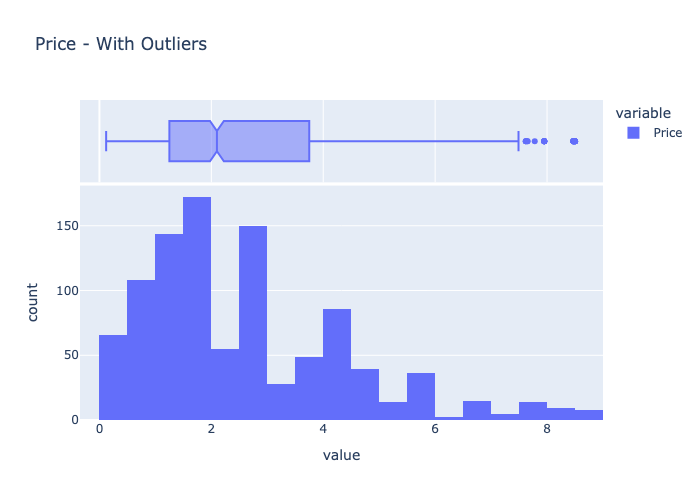

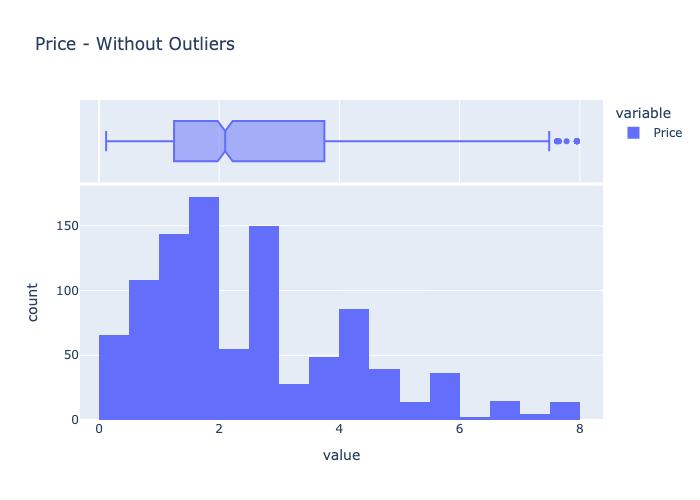

In [13]:
profile_serie(df_retail_limpio["Price"])

## Quantity Profile

Type                              int64
Number of observations         511566.0
Mean                           5.331877
Std                            4.570623
Min                                 1.0
25%                                 1.0
50%                                 3.0
75%                                10.0
Max                                23.0
Negative                              0
Negative (%)                      0.0 %
Zeros                                 0
Zeros (%)                         0.0 %
Kurt                          -0.458181
Skew                           0.793757
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   511566
Duplicate rows (%)              100.0 %
Total size in memory      4092660 bytes
dtype: object

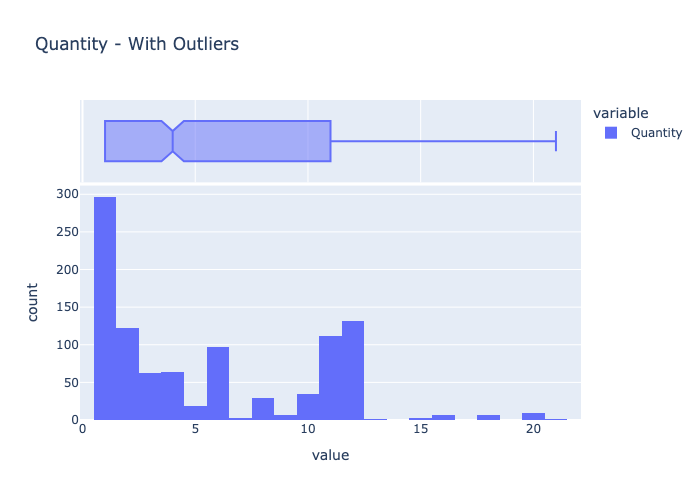

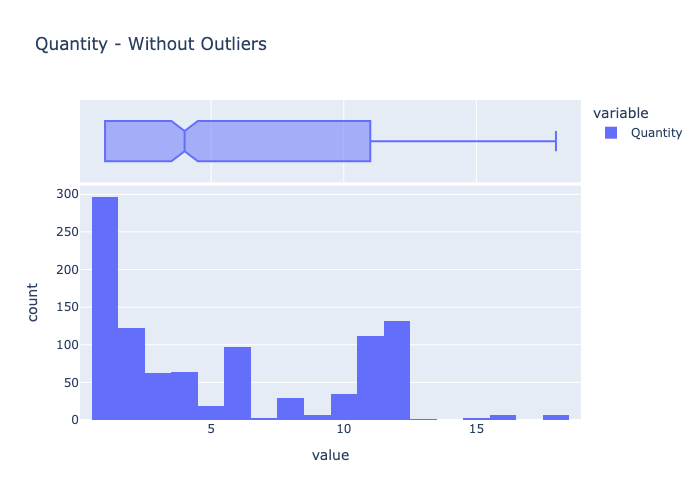

In [14]:
profile_serie(df_retail_limpio["Quantity"])

## Bivariant Analysis:

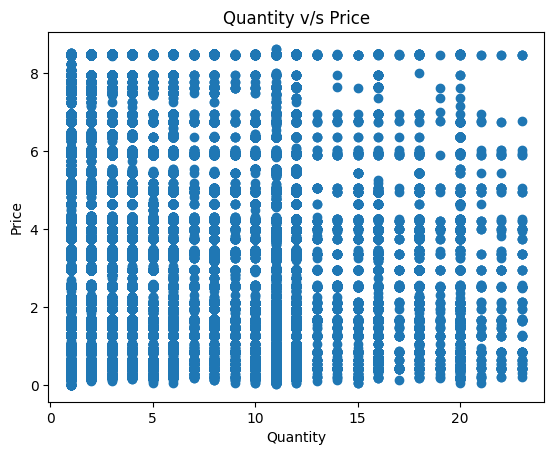

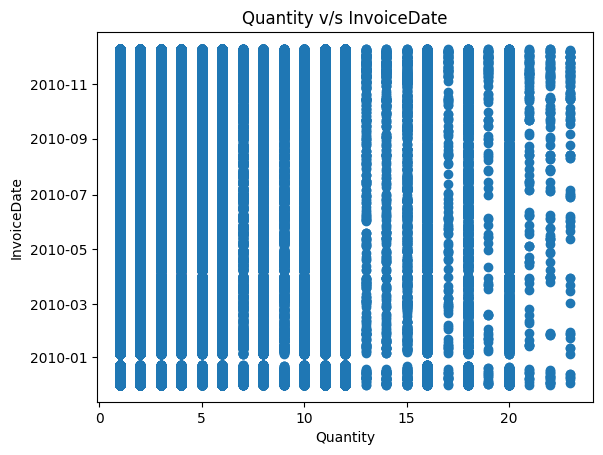

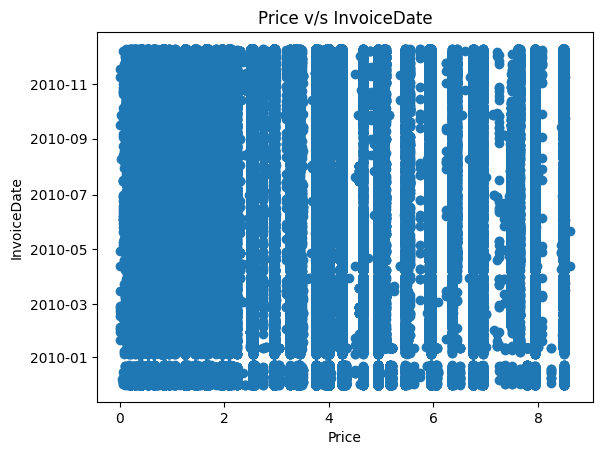

## Correlation:

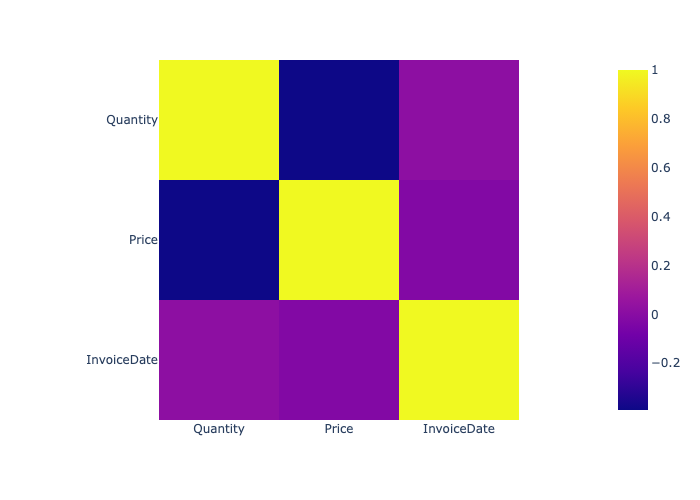

## Missing Matrix:

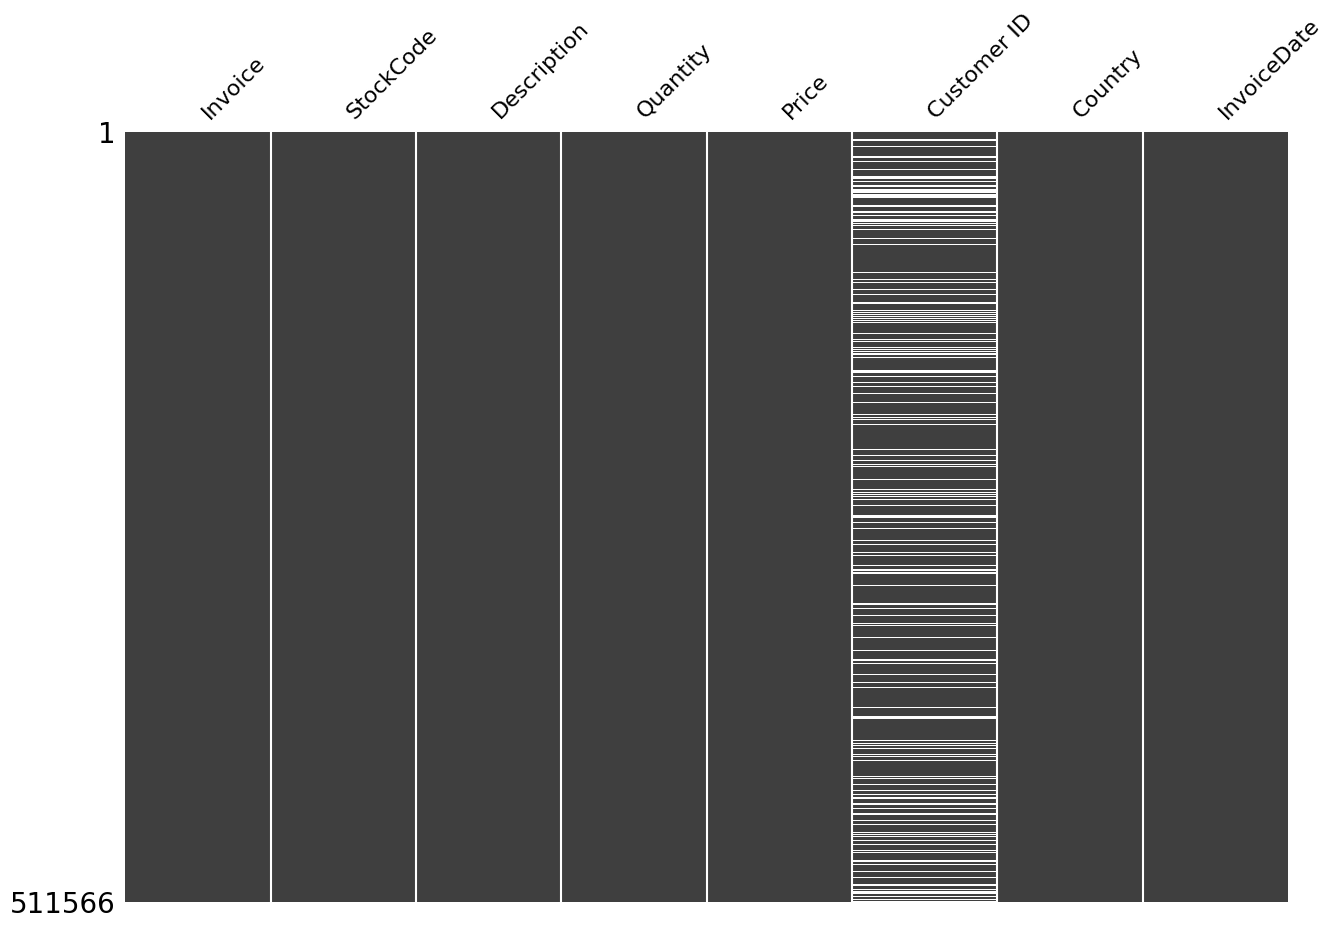

In [15]:
profile_df(df_retail_limpio)

Para la limpieza de los datos se trabajó en dos ejes principales: eliminar los registros con valores negativos en Price y Quantity, e imputar los outliers por la media respectiva de cada variable mediante el método del rango intercuartílico. Tras este tratamiento se eliminó aproximadamente un 2% del total original de observaciones, reduciendo el dataset de 525.461 a 511.566 registros.

Para identificar outliers se utilizó el método del rango intercuartílico (IQR). Este consiste en calcular la diferencia entre el percentil 75 (Q3) y el percentil 25 (Q1) de la variable. A partir de este rango se definen dos umbrales: el límite superior como Q3 + 1,5·IQR y el límite inferior como Q1 − 1,5·IQR. Todo registro que caiga fuera de estos límites es considerado un outlier y es imputado por la media de la variable correspondiente.* 

Con respecto a la distribución de Price y Quantity tras el tratamiento, ambas variables presentan una distribución más centrada en torno a la media, con una desviación estándar considerablemente menor a la observada antes del tratamiento. Además, el valor de skewness se aproxima a 1, lo que indica una distribución más simétrica y con colas menos pronunciadas, acercándose más a una distribución normal.

En cuanto al análisis bivariado, los gráficos de dispersión no muestran una tendencia clara, presentándose como nubes de puntos sin estructura aparente. No obstante, la matriz de correlaciones revela que Price y Quantity presentan una correlación negativa baja de -0,4. Este resultado es coherente con el concepto de economías de escala: a mayor volumen de compra de un producto, es esperable que su precio unitario disminuya.

*Fuente: Castrillo, M. (2023). Cómo identificar y tratar outliers con Python. Medium. Extraido de: https://medium.com/@martacasdelg/cómo-identificar-y-tratar-outliers-con-python-bf7dd530fc3

### 1.2.4 Obtención de TOPs [0.75 ptos]

Sin considerar los comentarios realizados en la sección 1.2 , *Don Mora* les pide obtener el **Top de 30 productos que generan más ganancias** para la tienda de retail. Deben considerar todo el registro temporal presente en el dataset y entregar la información en un gráfico de barras de los ingresos/cantidades v/s el nombre de los productos (Utilice `plotly`). ¿Los artículos más vendidos son los mismos que generan más ganancias?, Comente los resultados obtenidos.

**Resultados:**

In [29]:
# Se calcula la nueva columna de ingresos, que es el producto entre precio y cantidad.
df_retail["income"] = df_retail["Price"] * df_retail["Quantity"]

# Se agrupa según StockCode y se obtiene la suma de ingresos por cada producto.
df_retail_byproduct = df_retail.groupby("StockCode")[["income", "Quantity"]].sum().reset_index()

# Ordenarlos según ingresos de mayor a menor.
df_retail_byproduct = df_retail_byproduct.sort_values(by="income", ascending=False).reset_index(drop=True)

# Seleccionar los 30 productos con mayores ingresos.
df_retail_byproduct = df_retail_byproduct[df_retail_byproduct.index < 30]

# Convertir la variable StockCode a string para que se pueda plotear correctamente.
df_retail_byproduct["StockCode"] = df_retail_byproduct["StockCode"].astype(str)

display(df_retail_byproduct)

,StockCode,income,Quantity
0,22423,163051.46,12784
1,85123A,155825.52,57236
2,DOT,116401.99,1231
3,85099B,88922.48,48376
4,84879,72454.12,44484
5,22086,57870.20,17023
6,47566,49645.52,9269
7,84347,47672.49,13048
8,POST,46092.36,3754
9,21843,42333.85,3955


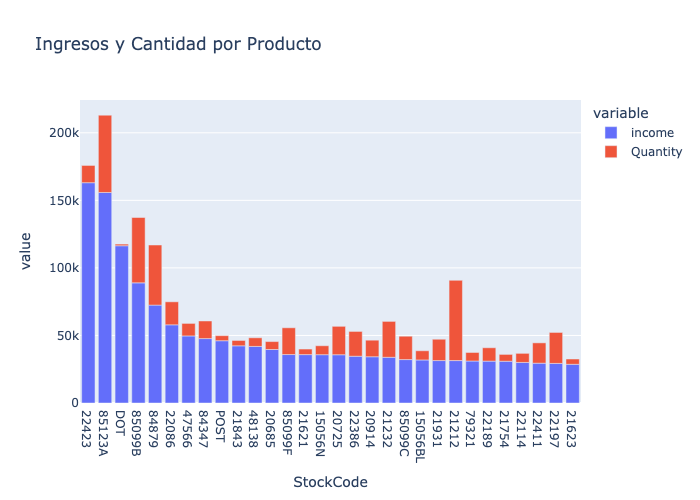

In [30]:
# Grafico de Ingresos y Cantidad por producto
fig = px.bar(df_retail_byproduct, x="StockCode", y=["income", "Quantity"], title="Ingresos y Cantidad por Producto")
fig.show(renderer="png")

Se definió que los ingresos corresponden al producto entre precio y cantidad vendida. Al analizar el gráfico de ingresos y cantidad agrupados por producto, se observa una tendencia general en que los productos más vendidos tienden a generar mayores ingresos. Sin embargo, esta relación no es perfecta: el producto con mayor cantidad vendida (85123A) no es el que reporta más ingresos, lo que sugiere que el precio unitario también juega un rol relevante. 

### 1.2.5 Visualización del registro temporal [0,75 ptos]

El dueño del retail en su afán por saber más sobre los datos de su firma les solicita que grafiquen las ventas respecto al tiempo. Con esto les aclara que durante el día tienen muchas variaciones en sus ventas, por lo que les recomienda que consideren el registro temporal como `año-mes-día`. ¿Es posible observar datos extraños?, Comente lo que observa del gráfico.

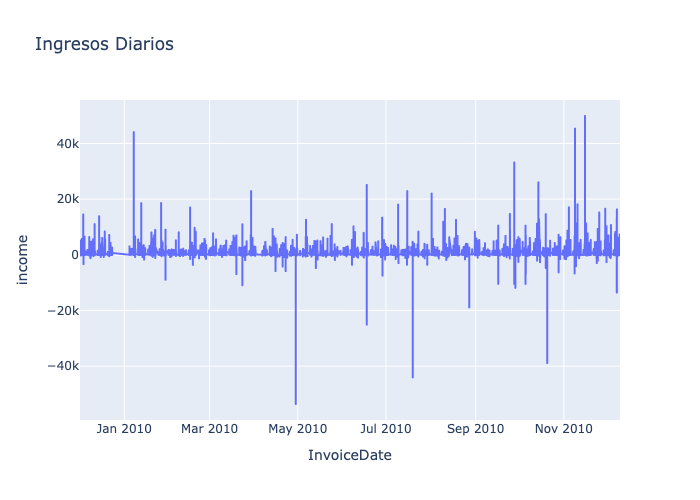

In [32]:
def plot_ventas(dataframe):
    df = dataframe.copy()

    # Agrupar por fecha y sumar los ingresos diarios
    df_daily_income = df.groupby("InvoiceDate")["income"].sum().reset_index()

    # Graficar los ingresos diarios
    fig = px.line(df_daily_income, x="InvoiceDate", y="income", title="Ingresos Diarios")
    fig.show(renderer="png")


plot_ventas(df_retail)

Para construir este gráfico se consideraron los ingresos como el producto entre precio y cantidad. Del gráfico no se aprecia una tendencia clara en el tiempo: se observa un comportamiento oscilatorio donde los ingresos diarios alternan entre valores bajos y peaks puntuales que decaen rápidamente, repitiéndose este patrón a lo largo de todo el período.

Respecto a datos extraños, se observan valores de ingreso negativos en varias fechas, lo cual no tiene interpretación económica directa como venta. Esto es consistente con lo identificado en el EDA previo, donde se detectaron precios y cantidades negativas en el dataset, los cuales no hacen sentido. 

# Conclusión
Eso ha sido todo para el lab de hoy, recuerden que el laboratorio tiene un plazo de entrega de una semana. Cualquier duda del laboratorio, no duden en contactarnos por mail o U-cursos.

![Gracias Totales!](https://i.pinimg.com/originals/65/ae/27/65ae270df87c3c4adcea997e48f60852.gif "bruno")


<br>
<center>
<img src="https://i.kym-cdn.com/photos/images/original/001/194/195/b18.png" width=100 height=50 />
</center>
<br>

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=87110296-876e-426f-b91d-aaf681223468' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>